# Model 3: Random Forest

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE


In [2]:
df = pd.read_csv('../data/final/ml_ready_dataset.csv')
X = df.select_dtypes(exclude=['object', 'string']).drop(columns=['is_returned'], errors='ignore')
y = df['is_returned']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Original training shape: {X_train.shape}")


Original training shape: (77599, 41)


### Training the Baseline Random Forest
First, train a Random Forest with 100 trees using default parameters.

In [3]:
rf_baseline = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf_baseline.fit(X_train, y_train)

train_acc = accuracy_score(y_train, rf_baseline.predict(X_train))
test_acc = accuracy_score(y_test, rf_baseline.predict(X_test))

print(f"Baseline Random Forest Training Accuracy: {train_acc * 100:.2f}%")
print(f"Baseline Random Forest Testing Accuracy: {test_acc * 100:.2f}%")


Baseline Random Forest Training Accuracy: 99.96%
Baseline Random Forest Testing Accuracy: 90.61%


**Overfitting is still present:** Just like the single Decision Tree, the baseline Random Forest hit **99.96% Training Accuracy**. Because constrained the `max_depth`, every single tree in the forest grew deep enough to memorize the training data.

**The Magic of Bagging:** Look at the Testing Accuracy! Our unconstrained single Decision Tree scored 85.90% on the test set. By simply switching to a Random Forest our Testing Accuracy shot up to **90.61%**. 

### Hyperparameter Tuning

In [4]:
param_grid = {
    'n_estimators': [100, 150],
    'max_depth': [6, 8, 10],
    'min_samples_split': [10, 50]
}

grid_search = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=1
)

grid_search.fit(X_train, y_train)
best_rf = grid_search.best_estimator_

print(f"Best Hyperparameters Discovered: {grid_search.best_params_}")
print(f"Best Cross-Validated ROC-AUC: {grid_search.best_score_:.4f}")


Best Hyperparameters Discovered: {'max_depth': 10, 'min_samples_split': 50, 'n_estimators': 150}
Best Cross-Validated ROC-AUC: 0.9141


Our Performance Ladder continues to prove itself! 
  - Logistic Regression ROC-AUC: **0.8968**
  - Single Decision Tree ROC-AUC: **0.9109**
  - Optimized Random Forest ROC-AUC: **0.9141**

### Evaluating the Optimized Ensemble

Optimized Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.88      0.92     16517
           1       0.55      0.80      0.65      2883

    accuracy                           0.87     19400
   macro avg       0.76      0.84      0.79     19400
weighted avg       0.90      0.87      0.88     19400

Final ROC-AUC Score: 0.9130



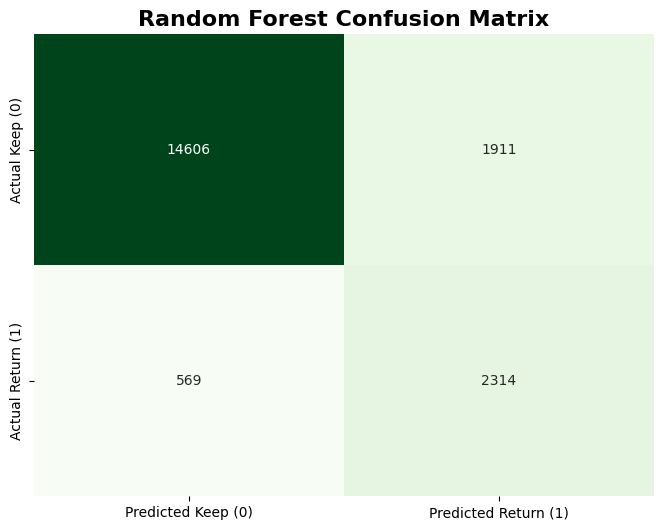

In [5]:
preds = best_rf.predict(X_test)
probs = best_rf.predict_proba(X_test)[:, 1]

print("Optimized Random Forest Classification Report:")
print(classification_report(y_test, preds))
print(f"Final ROC-AUC Score: {roc_auc_score(y_test, probs):.4f}\n")

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Predicted Keep (0)', 'Predicted Return (1)'],
            yticklabels=['Actual Keep (0)', 'Actual Return (1)'])
plt.title('Random Forest Confusion Matrix', fontsize=16, fontweight='bold')
plt.show()


### Perfect Balance: Precision vs. Recall
**Trading Recall for Precision:** Our single Decision Tree had a Recall of 82% but a Precision of 52%. By switching to the Random Forest ensemble, our Recall dropped slightly to 80%, but our Precision jumped to 55%!

- **Why is this better?** A single Decision Tree is "greedy"—it will aggressively flag anything that looks mildly risky, resulting in a high Recall but lots of false alarms (lower Precision). The Random Forest requires *consensus*. Because multiple trees have to agree that an order is risky before it gets flagged, the model becomes slightly more conservative. 


C:\Users\ASUS\AppData\Local\Temp\ipykernel_29532\2155460471.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances, x='Importance', y='Feature', palette="mako")


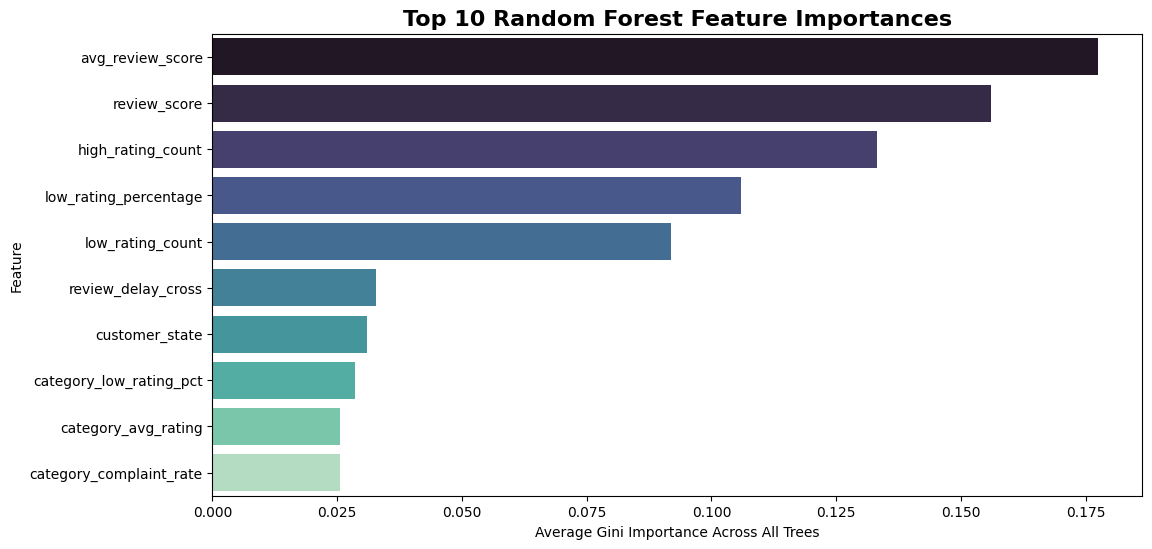

In [6]:
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
}).sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=importances, x='Importance', y='Feature', palette="mako")
plt.title('Top 10 Random Forest Feature Importances', fontsize=16, fontweight='bold')
plt.xlabel('Average Gini Importance Across All Trees')
plt.ylabel('Feature')
plt.show()


1. In the single Decision Tree, `review_score` was a tyrant, controlling 70% of all splits! The Random Forest completely broke that monopoly. The top feature (`avg_review_score`) now only accounts for about 17.5% of the importance, and the importance is beautifully distributed across the top 10 features.

2. Random Forests use a technique called *Feature Subsetting*. At every split, each tree is only allowed to look at a random handful of features. This physically forced the trees to ignore `review_score` sometimes and learn how to extract value from other correlated features (like `high_rating_count` or `low_rating_percentage`).

3. Once again, our engineered category signals (`category_low_rating_pct`, `category_avg_rating`) and the label-encoded `customer_state` sit proudly in the top 10, confirming that tree ensembles are the perfect architecture for our feature engineering strategy.

Let's move to **Notebook 04: XGBoost**, where we switch from "averaging independent trees" to "training sequential trees to correct each other's mistakes"!

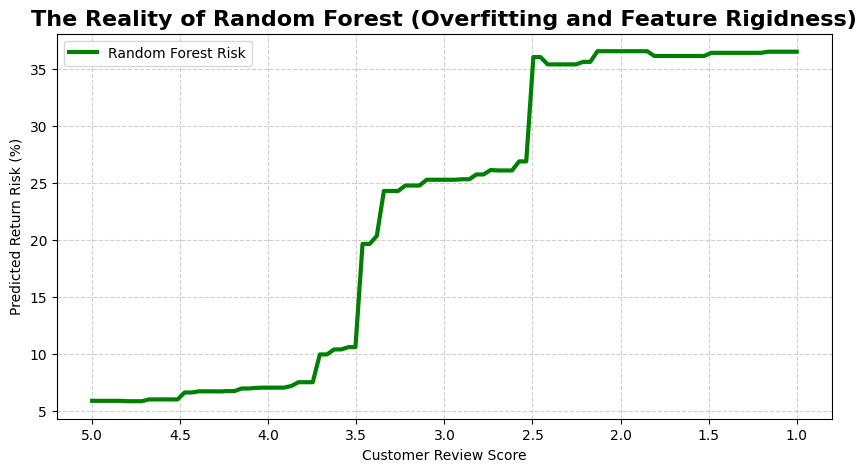

In [8]:
# Create a perfectly average customer
import numpy as np
base_customer = X.median().to_frame().T
review_scores = np.linspace(1.0, 5.0, 100)
predicted_risks = []

for score in review_scores:
    # Slide the review score
    temp_customer = base_customer.copy()
    temp_customer["review_score"] = score
    temp_customer["avg_review_score"] = score
    risk = best_rf.predict_proba(temp_customer)[0][1]
    predicted_risks.append(risk * 100)

plt.figure(figsize=(10, 5))
plt.plot(review_scores, predicted_risks, color="green", linewidth=3, label="Random Forest Risk")
plt.title("The Reality of Random Forest (Overfitting and Feature Rigidness)", fontsize=16, fontweight="bold")
plt.xlabel("Customer Review Score")
plt.ylabel("Predicted Return Risk (%)")
plt.gca().invert_xaxis()  # 5.0 (good) down to 1.0 (bad)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()


### The Smoothed Staircase 

1. Compare this to the single Decision Tree's graph! Instead of 3 massive, rigid blocks, we now have dozens of tiny steps. By averaging 150 different trees, the Random Forest created a much smoother, more realistic risk curve between 5.0 and 2.5 stars. 

2. Look closely at the left side of the graph. As the review score drops from 2.5 down to 1.0, the predicted risk hits a ceiling of ~36% and goes completely, perfectly flat! Why? Because Random Forests cannot **extrapolate**. They are built by partitioning data into boxes. If a customer falls into the worst "box" the forest has ever seen, the forest just assigns the average risk of that box, no matter how much worse the review score gets.


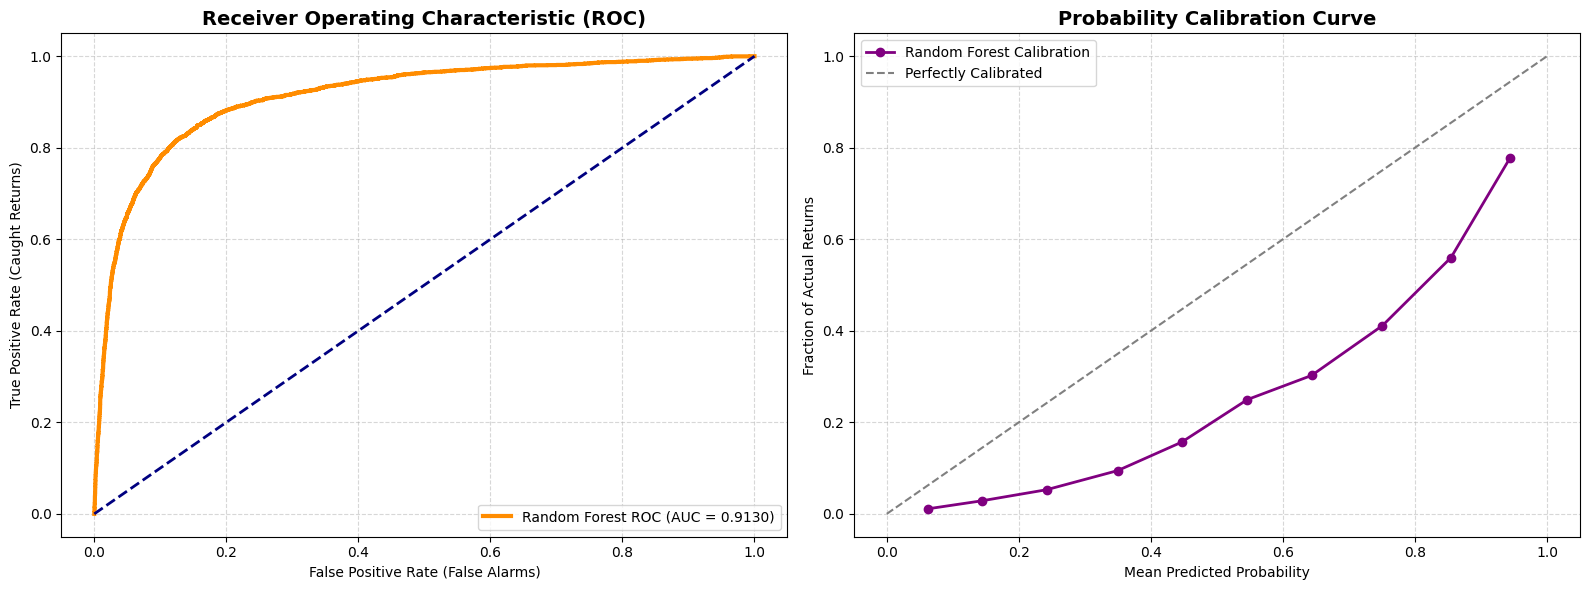

In [10]:
from sklearn.metrics import roc_curve, auc
from sklearn.calibration import calibration_curve

# 1. Calculate ROC Curve data
fpr, tpr, _ = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

# 2. Calculate Calibration Curve data
prob_true, prob_pred = calibration_curve(y_test, probs, n_bins=10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: ROC Curve ---
axes[0].plot(fpr, tpr, color='darkorange', lw=3, label=f'Random Forest ROC (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_title('Receiver Operating Characteristic (ROC)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('False Positive Rate (False Alarms)')
axes[0].set_ylabel('True Positive Rate (Caught Returns)')
axes[0].legend(loc="lower right")
axes[0].grid(True, linestyle='--', alpha=0.5)

# --- Plot 2: Calibration Curve ---
axes[1].plot(prob_pred, prob_true, marker='o', linewidth=2, color='purple', label='Random Forest Calibration')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')
axes[1].set_title('Probability Calibration Curve', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Mean Predicted Probability')
axes[1].set_ylabel('Fraction of Actual Returns')
axes[1].legend(loc="upper left")
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


### The Calibration Curve:]
Look at the graph on the right (Probability Calibration Curve). If the model was perfectly confident, the purple line would exactly trace the gray dotted diagonal line. Instead, our purple line sits entirely **below** the diagonal. 

- **Over-Predicting Risk:** What does this mean? It means the Random Forest is heavily over-estimating the actual risk! For example, when the model outputs an 80% risk probability (x-axis), the *actual* fraction of real-world returns in that bucket is only about 50% (y-axis). 

- **Why did this happen?** Remember when we set `class_weight='balanced'` during training? Because the real-world return rate is only 12%, we forced the algorithm to heavily penalize itself for missing returns. To compensate, the Random Forest aggressively over-predicted the positive class. 

- **The Verdict:** While the ROC Curve (left) proves the model is fantastic at *ranking* customers (knowing who is riskier than who), the Calibration Curve proves we **cannot trust the raw percentages it outputs**. A predicted 90% risk isn't actually a 90% risk; it's an artificially inflated number used to trigger the threshold.

To fix this, we need an algorithm that natively optimizes a logistical loss function to produce true, mathematically calibrated probabilities. Let's move to **Notebook 04: XGBoost**!
